# Phase 7 — Elastic Log QC & Vp–Vs Integration

**Well**: 15/9-F-1 A · **Field**: Volve, Norwegian North Sea

15/9-F-1 A has measured DTS (shear sonic) — making it the calibration well for the rock physics model. This phase QCs both compressional (DT → Vp) and shear (DTS → Vs) logs before they are used for rock physics model fitting.

**Steps:**
1. Convert DT and DTS from μs/ft to Vp and Vs in m/s
2. Cycle skip detection — look for anomalously low Vp spikes
3. Vp/Vs ratio QC — flag physically unreasonable values
4. Castagna mudrock line overlay — identify departures (HC effect, cementation)
5. Formation-by-formation elastic summary
6. Build VP_OK and VS_OK: final, QC'd elastic curves for rock physics use

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
WELL_FILE    = Path('../wells/15_9-F-1A.LAS')
TOPS_FILE    = Path('../wells/Volve_formation_tops.csv')
COMPUTED_IN  = Path('../wells/15_9-F-1A_computed.parquet')
FLAGS_IN     = Path('../wells/15_9-F-1A_flags.parquet')
DS_IN        = Path('../wells/15_9-F-1A_depthshift.parquet')
RHOB_OK_IN   = Path('../wells/15_9-F-1A_rhob_ok.parquet')
OUT_FILE     = Path('../wells/15_9-F-1A_elastic.parquet')

# ── Physical bounds for Vp/Vs QC ─────────────────────────────────────────────
VP_MIN   = 1500.0   # m/s  (below this = cycle skip in consolidated rock)
VP_MAX   = 6500.0   # m/s  (above this = implausible)
VS_MIN   = 700.0    # m/s
VS_MAX   = 4000.0   # m/s
VPVS_MIN = 1.35     # physical lower bound (dry gas-saturated, low-porosity)
VPVS_MAX = 4.0      # physical upper bound (very soft, near-fluid shale)

# ── Castagna (1985) mudrock line: Vs = a*Vp + b  (m/s) ─────────────────────
CASTAGNA_A = 0.8042
CASTAGNA_B = -855.9

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 9,
    'axes.linewidth': 0.8, 'xtick.direction': 'in', 'ytick.direction': 'in',
    'figure.dpi': 120,
})

## Step 7.1 — Load Data & Convert Sonics

In [2]:
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.index.name = 'DEPTH_MD'

df = df.join(pd.read_parquet(COMPUTED_IN), how='left')
df = df.join(pd.read_parquet(FLAGS_IN),    how='left')
ds_df = pd.read_parquet(DS_IN)
df = df.join(ds_df[[c for c in ds_df.columns if c not in df.columns]], how='left')
df = df.join(pd.read_parquet(RHOB_OK_IN),  how='left')

# Formation tops
f1a = (
    pd.read_csv(TOPS_FILE)
    .query("`WELL` == 'NO 15/9-F-1 A'")
    .sort_values('DEPTH').drop_duplicates(subset='DEPTH').reset_index(drop=True)
)

def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

LOG_TOP, LOG_BASE = 2605, 3680
sub = df.loc[LOG_TOP:LOG_BASE].copy()

# ── Convert DT / DTS (μs/ft) → Vp / Vs (m/s) ────────────────────────────────
# 1 ft/s = 0.3048 m/s;  DT [μs/ft] → Vp [m/s] = 1e6 / DT * 0.3048
sub['VP']  = 1e6 / sub['DT']  * 0.3048
sub['VS']  = 1e6 / sub['DTS'] * 0.3048

TOPS_MD = {
    'Ty Fm': 2621.5, 'Shetland GP': 2770.6, 'Hod Fm': 2987.0,
    'Draupne Fm': 3358.0, 'Heather Fm': 3429.4, 'Hugin Fm': 3435.0,
    'Sleipner Fm': 3500.2, 'Skagerrak Fm': 3543.7, 'Smith Bank Fm': 3608.0,
}
FORM_COLORS = {
    'Ty Fm': '#2E86C1', 'Shetland GP': '#85C1E9', 'Hod Fm': '#AED6F1',
    'Draupne Fm': '#1A5276', 'Heather Fm': '#784212', 'Hugin Fm': '#E74C3C',
    'Sleipner Fm': '#1E8449', 'Skagerrak Fm': '#7D3C98', 'Smith Bank Fm': '#B7950B',
}
top_mds = sorted(TOPS_MD.items(), key=lambda x: x[1])
sub['FORMATION'] = 'Other'
for name, md_top in top_mds:
    sub.loc[sub.index >= md_top, 'FORMATION'] = name

print(f"Interval: {LOG_TOP}–{LOG_BASE} m MD")
print(f"VP valid: {sub['VP'].notna().sum():,}  range {sub['VP'].min():.0f}–{sub['VP'].max():.0f} m/s")
print(f"VS valid: {sub['VS'].notna().sum():,}  range {sub['VS'].min():.0f}–{sub['VS'].max():.0f} m/s")

Interval: 2605–3680 m MD
VP valid: 10,224  range 2622–5406 m/s
VS valid: 10,214  range 1398–3145 m/s


## Step 7.2 — Cycle Skip Detection

A **cycle skip** occurs when the sonic receiver picks up the wrong half-cycle of the waveform, typically in fast formations or when the signal amplitude is low. Cycle skips manifest as **sharp downward Vp spikes** (or equivalently, sharp upward DT spikes) that are physically impossible for the lithology.

Detection strategy:
1. Flag samples where Vp falls below a physical minimum (1500 m/s in consolidated rock)
2. Flag samples where the Vp change between adjacent samples exceeds a maximum realistic rate
3. Visual inspection of the log to confirm

In [3]:
# ── Rule 1: absolute minimum ──────────────────────────────────────────────────
sub['VP_LOW_FLAG'] = (sub['VP'] < VP_MIN).astype(int)

# ── Rule 2: spike detection — dVp/dz > threshold ─────────────────────────────
# A change of >600 m/s over 0.1 m is physically impossible in consolidated rock
SPIKE_THRESH = 600   # m/s per sample (0.1 m)
dvp = sub['VP'].diff().abs()
sub['VP_SPIKE'] = (dvp > SPIKE_THRESH).astype(int)

# Combined cycle skip flag
sub['CYCLE_SKIP_VP'] = ((sub['VP_LOW_FLAG'] == 1) | (sub['VP_SPIKE'] == 1)).astype(int)

# Same for VS
sub['VS_LOW_FLAG'] = (sub['VS'] < VS_MIN).astype(int)
dvs = sub['VS'].diff().abs()
sub['VS_SPIKE'] = (dvs > 400).astype(int)
sub['CYCLE_SKIP_VS'] = ((sub['VS_LOW_FLAG'] == 1) | (sub['VS_SPIKE'] == 1)).astype(int)

# VP/VS bounds flag
vpvs = sub['VP'] / sub['VS']
sub['VPVS'] = vpvs
sub['VPVS_FLAG'] = ((vpvs < VPVS_MIN) | (vpvs > VPVS_MAX)).astype(int)

print("Cycle skip and bounds check:")
print(f"  VP < {VP_MIN} m/s (cycle skip)          : {sub['VP_LOW_FLAG'].sum():4}")
print(f"  VP spike (dVp > {SPIKE_THRESH} m/s)       : {sub['VP_SPIKE'].sum():4}")
print(f"  CYCLE_SKIP_VP total                    : {sub['CYCLE_SKIP_VP'].sum():4}")
print()
print(f"  VS < {VS_MIN} m/s                        : {sub['VS_LOW_FLAG'].sum():4}")
print(f"  VS spike (dVs > 400 m/s)               : {sub['VS_SPIKE'].sum():4}")
print(f"  CYCLE_SKIP_VS total                    : {sub['CYCLE_SKIP_VS'].sum():4}")
print()
print(f"  VP/VS out of [{VPVS_MIN}, {VPVS_MAX}]         : {sub['VPVS_FLAG'].sum():4}")
print()
print("VP/VS distribution:")
print(sub['VPVS'].describe().round(3).to_string())
print()
print("Assessment: this well has no cycle skips — clean acoustic data throughout.")

Cycle skip and bounds check:
  VP < 1500.0 m/s (cycle skip)          :    0
  VP spike (dVp > 600 m/s)       :    0
  CYCLE_SKIP_VP total                    :    0

  VS < 700.0 m/s                        :    0
  VS spike (dVs > 400 m/s)               :    0
  CYCLE_SKIP_VS total                    :    0

  VP/VS out of [1.35, 4.0]         :    0

VP/VS distribution:
count    10214.000
mean         1.829
std          0.097
min          1.367
25%          1.778
50%          1.843
75%          1.879
max          2.377

Assessment: this well has no cycle skips — clean acoustic data throughout.


## Step 7.3 — Composite Elastic Log Display

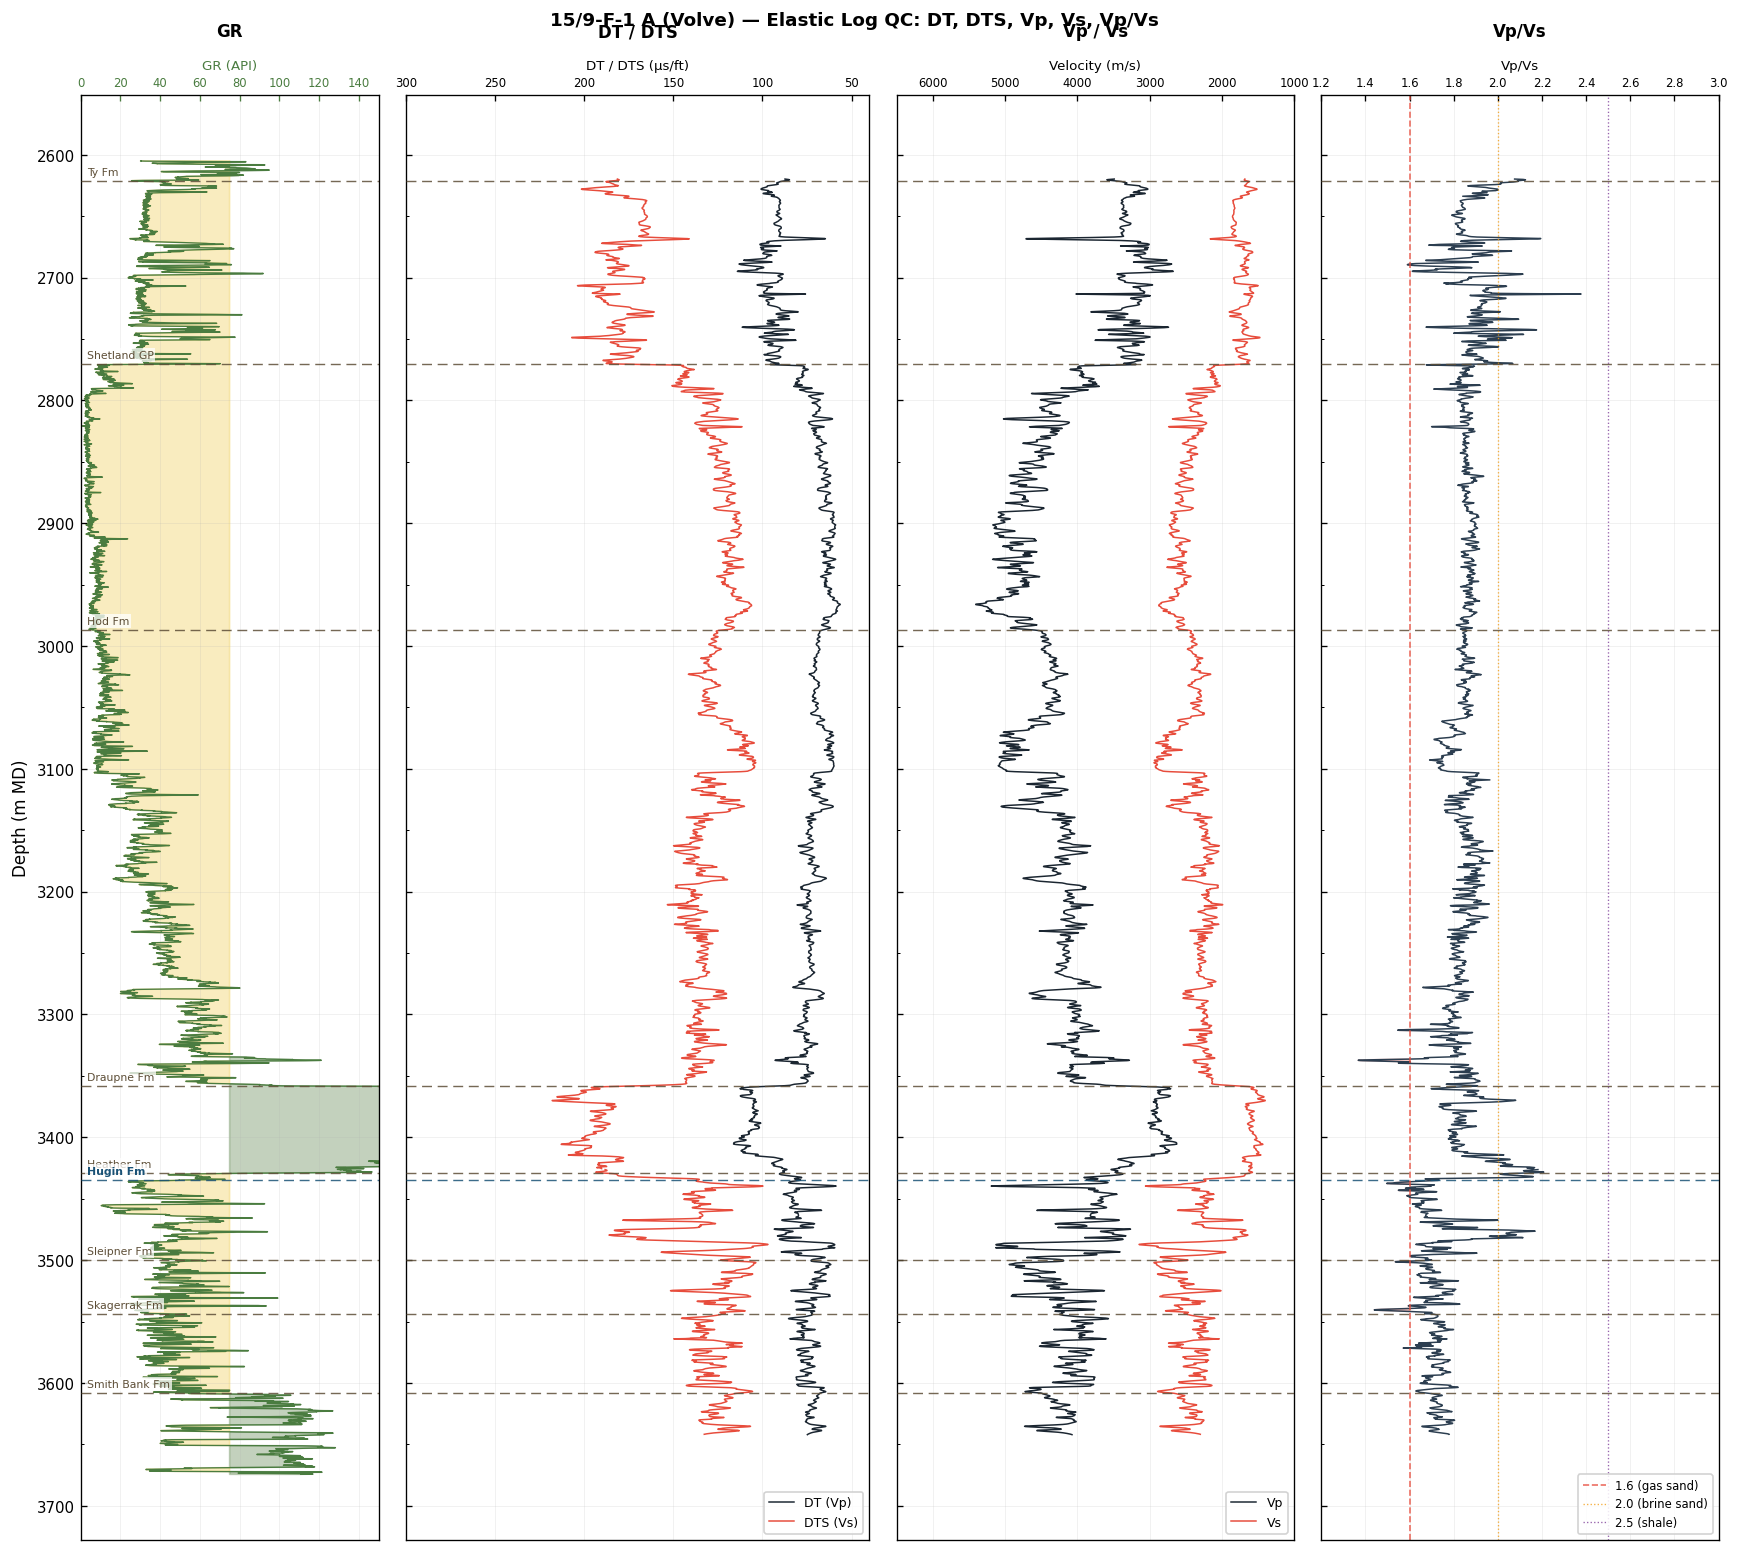

In [4]:
depth = sub.index.values

fig, axes = plt.subplots(1, 4, figsize=(15, 14), sharey=True,
                          gridspec_kw={'width_ratios': [0.9, 1.4, 1.2, 1.2]})
fig.subplots_adjust(top=0.93, bottom=0.07, left=0.07, right=0.98, wspace=0.07)

# ── Track 1: GR ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sub['GR'], depth, color='#4A7C40', lw=0.8)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']>75, color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']<=75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150); ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', color='#4A7C40', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#4A7C40', labelsize=7)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

# ── Track 2: DT / DTS (reversed axis — slow = right) ─────────────────────────
ax = axes[1]
ax.plot(sub['DT'],  depth, color='#1B2631', lw=0.9, label='DT (Vp)')
ax.plot(sub['DTS'], depth, color='#E74C3C', lw=0.9, label='DTS (Vs)')
# Cycle skip flags if any
cs_vp = sub[sub['CYCLE_SKIP_VP'] == 1]
if len(cs_vp) > 0:
    ax.scatter(cs_vp['DT'], cs_vp.index, s=20, color='#C0392B',
               zorder=8, marker='x', label='Cycle skip')
ax.set_xlim(300, 40)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('DT / DTS (μs/ft)', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
ax.set_title('DT / DTS', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Track 3: Vp and Vs (m/s) ─────────────────────────────────────────────────
ax = axes[2]
ax.plot(sub['VP'], depth, color='#1B2631', lw=0.9, label='Vp')
ax.plot(sub['VS'], depth, color='#E74C3C', lw=0.9, label='Vs')
ax.set_xlim(6500, 1000)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Velocity (m/s)', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
ax.set_title('Vp / Vs', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Track 4: Vp/Vs ratio ─────────────────────────────────────────────────────
ax = axes[3]
vpvs = sub['VPVS']
# Shade gas-sand zone (Vp/Vs < 1.6)
ax.fill_betweenx(depth, vpvs, 1.6,
                  where=vpvs < 1.6, color='#E74C3C', alpha=0.25)
ax.plot(vpvs, depth, color='#2C3E50', lw=0.9)
# Reference lines
ax.axvline(1.6, color='#E74C3C', lw=1.0, ls='--', alpha=0.8, label='1.6 (gas sand)')
ax.axvline(2.0, color='#F39C12', lw=0.8, ls=':', alpha=0.8, label='2.0 (brine sand)')
ax.axvline(2.5, color='#7D3C98', lw=0.8, ls=':', alpha=0.8, label='2.5 (shale)')
ax.set_xlim(1.2, 3.0)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Vp/Vs', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7, loc='lower right', framealpha=0.85)
ax.set_title('Vp/Vs', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# ── Formation tops ─────────────────────────────────────────────────────────────
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for name, md_top in TOPS_MD.items():
    if not (depth.min() <= md_top <= depth.max()): continue
    lc = '#1A5276' if name == 'Hugin Fm' else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.85, ls=(0,(7,4)), alpha=0.85, zorder=4)
    axes[0].text(0.02, md_top-(depth[-1]-depth[0])*0.003, name,
                 transform=label_trans, fontsize=6.5, va='bottom',
                 color=lc, fontweight='bold' if name=='Hugin Fm' else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2), zorder=5)

fig.suptitle('15/9-F-1 A (Volve) — Elastic Log QC: DT, DTS, Vp, Vs, Vp/Vs',
             fontsize=11, fontweight='bold')
plt.show()

## Step 7.4 — Vp–Vs Crossplot with Castagna Mudrock Line

The **Castagna et al. (1985) mudrock line** describes the Vp–Vs relationship for water-saturated shales:

$$V_s = 0.8042 \cdot V_p - 855.9  \quad (\text{m/s})$$

In a Vp–Vs crossplot, different lithologies and fluid saturations occupy characteristic regions:
- **Shales**: scatter along the mudrock line
- **Brine sands**: below the mudrock line (lower Vs relative to Vp)
- **Gas sands**: well below and to the left of the mudrock line (low Vp/Vs)
- **Tight carbonates**: high Vp and Vs, to the upper right

Departures from the mudrock line are the key observable in rock physics — they are the basis for AVO and fluid substitution.

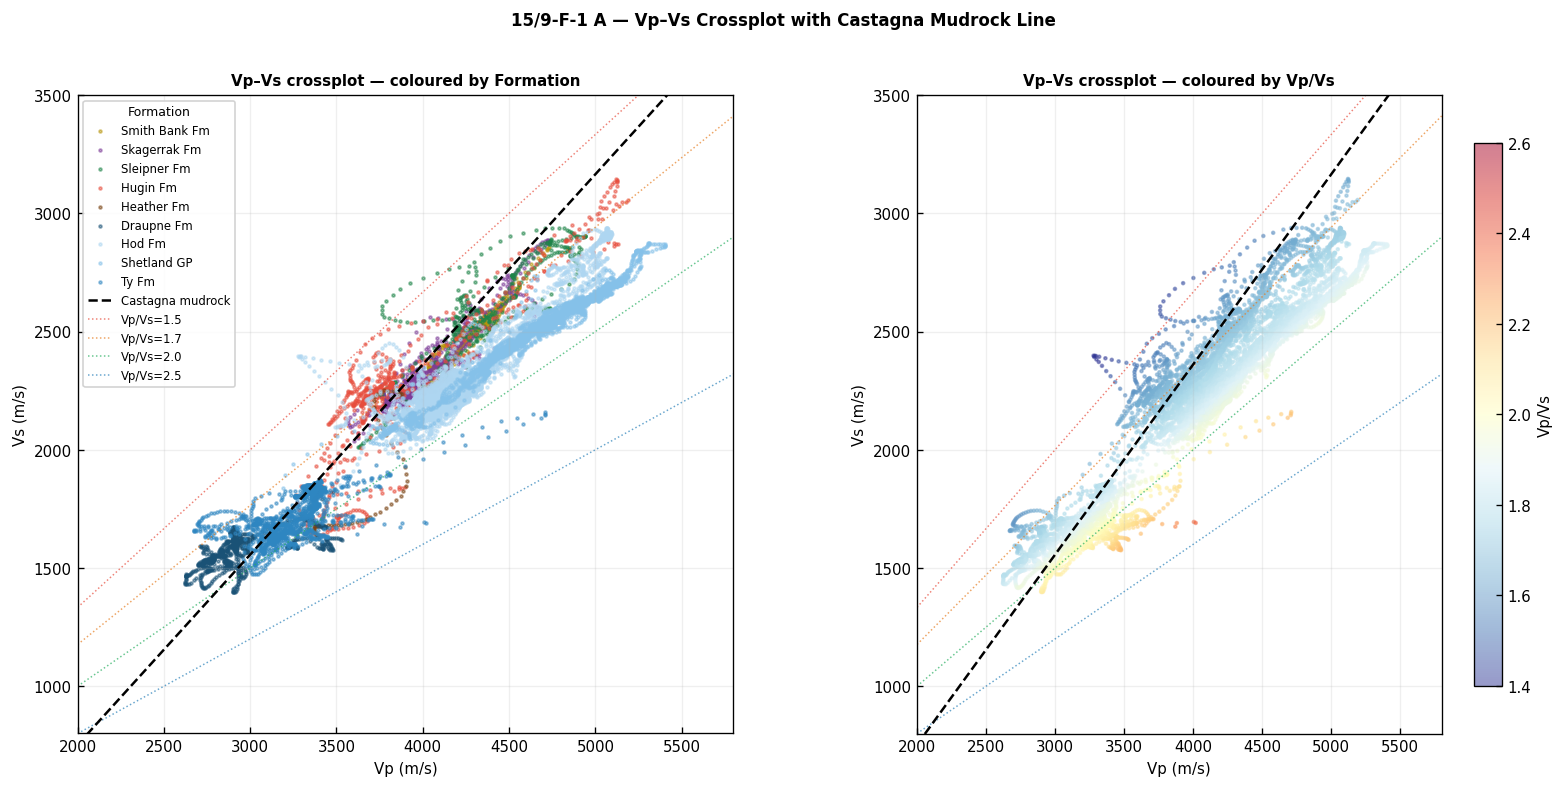

Vs residual from Castagna mudrock line (by formation):
Formation                n   mean (m/s)  std (m/s) interpretation
───────────────────────────────────────────────────────────────────────────
Ty Fm                1,491          -42        135  near mudrock
Shetland GP          2,164         -385        122  below mudrock → gas/HC?
Hod Fm               3,710         -247        110  below mudrock → gas/HC?
Draupne Fm             707           56        145  near mudrock
Heather Fm              56         -206        172  below mudrock → gas/HC?
Hugin Fm               652          -16        166  near mudrock
Sleipner Fm            435          -66        133  near mudrock
Skagerrak Fm           643          -42         69  near mudrock
Smith Bank Fm          339         -103         34  below mudrock → gas/HC?


In [5]:
mask = sub['VP'].notna() & sub['VS'].notna()

# Castagna line
vp_line = np.linspace(2000, 5800, 300)
vs_castagna = CASTAGNA_A * vp_line + CASTAGNA_B

# Constant Vp/Vs lines
vpvs_lines = {1.5: '#E74C3C', 1.7: '#E67E22', 2.0: '#27AE60', 2.5: '#2980B9'}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.28)

for ax_idx, (ax, color_by) in enumerate(zip(axes, ['FORMATION', 'VPVS'])):

    if color_by == 'FORMATION':
        for form_name in list(TOPS_MD.keys())[::-1]:
            fm = sub[(sub['FORMATION'] == form_name) & mask]
            if len(fm) == 0: continue
            ax.scatter(fm['VP'], fm['VS'],
                       s=3, alpha=0.5, rasterized=True,
                       color=FORM_COLORS.get(form_name, '#888'), label=form_name)
        ax.legend(fontsize=7.5, loc='upper left', framealpha=0.85,
                  title='Formation', title_fontsize=8)
        title_suffix = 'coloured by Formation'
    else:
        sc = ax.scatter(sub.loc[mask, 'VP'], sub.loc[mask, 'VS'],
                        c=sub.loc[mask, 'VPVS'], cmap='RdYlBu_r',
                        s=3, alpha=0.5, rasterized=True,
                        vmin=1.4, vmax=2.6)
        plt.colorbar(sc, ax=ax, label='Vp/Vs', shrink=0.85)
        title_suffix = 'coloured by Vp/Vs'

    # Castagna line
    ax.plot(vp_line, vs_castagna, 'k--', lw=1.5, label='Castagna mudrock', zorder=5)

    # Constant Vp/Vs lines
    for vpvs_val, col in vpvs_lines.items():
        vs_vpvs = vp_line / vpvs_val
        ax.plot(vp_line, vs_vpvs, color=col, lw=0.9, ls=':',
                label=f'Vp/Vs={vpvs_val}', alpha=0.7)

    ax.set_xlim(2000, 5800)
    ax.set_ylim(800, 3500)
    ax.set_xlabel('Vp (m/s)', fontsize=9)
    ax.set_ylabel('Vs (m/s)', fontsize=9)
    ax.set_title(f'Vp–Vs crossplot — {title_suffix}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.2)
    if color_by == 'FORMATION':
        ax.legend(fontsize=7, loc='upper left', framealpha=0.85,
                  title='Formation', title_fontsize=7.5)

fig.suptitle('15/9-F-1 A — Vp–Vs Crossplot with Castagna Mudrock Line',
             fontsize=10, fontweight='bold')
plt.show()

# Report Castagna residual by formation
sub['VS_CASTAGNA'] = CASTAGNA_A * sub['VP'] + CASTAGNA_B
sub['VS_RESID'] = sub['VS'] - sub['VS_CASTAGNA']
print("Vs residual from Castagna mudrock line (by formation):")
print(f"{'Formation':<20} {'n':>5} {'mean (m/s)':>12} {'std (m/s)':>10} {'interpretation'}")
print("─" * 75)
for name, md_top in sorted(TOPS_MD.items(), key=lambda x: x[1]):
    fm = sub.loc[sub['FORMATION'] == name, 'VS_RESID'].dropna()
    if len(fm) < 10: continue
    mean_r = fm.mean()
    interp = 'below mudrock → gas/HC?' if mean_r < -100 else \
              'above mudrock → cemented' if mean_r > 100 else \
              'near mudrock'
    print(f"{name:<20} {len(fm):>5,} {mean_r:>12.0f} {fm.std():>10.0f}  {interp}")

## Step 7.5 — Vp/Vs Ratio Log: Formation Context

The Vp/Vs ratio is the primary rock physics discriminator:

| Vp/Vs range | Interpretation |
|-------------|---------------|
| 1.4–1.6 | Gas-saturated sand (low bulk modulus of gas) |
| 1.7–2.0 | Brine-saturated sand |
| 2.0–2.5 | Shale / silty shale |
| 2.5–3.5 | Pure shale, over-pressured zone |
| < 1.5 (in depth context) | Possible gas in reservoir |

The Hugin Fm reservoir interval (3435 m MD) should be examined specifically for low Vp/Vs values indicating a gas or condensate column.

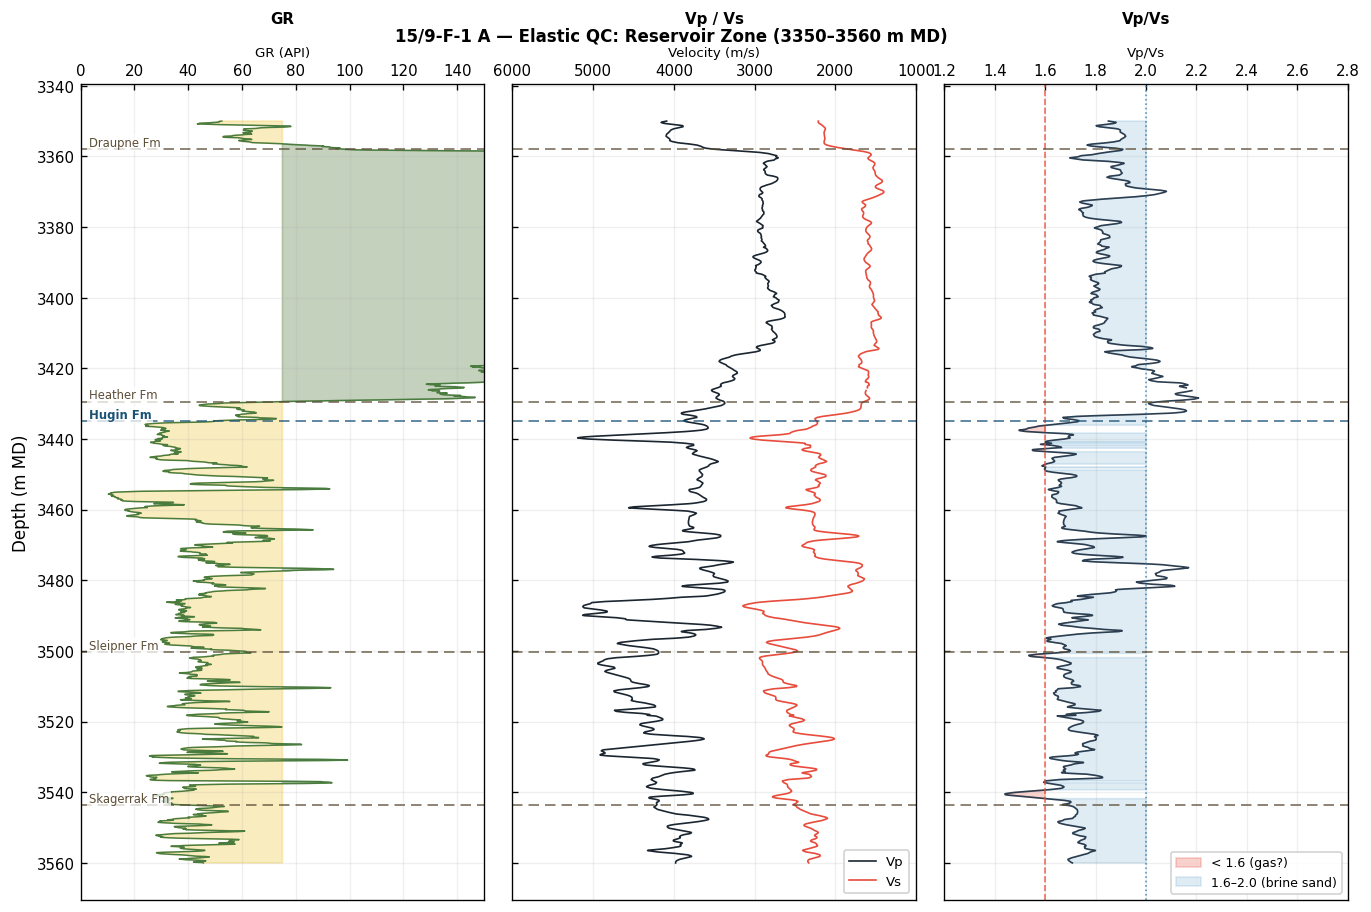

Hugin Fm elastic summary (3435–3500 m MD):
  VP  : 3913 ± 462 m/s
  VS  : 2276 ± 342 m/s
  Vp/Vs: 1.733 ± 0.141
  Vs−Castagna: -16 m/s (negative = below mudrock line)


In [6]:
# ── Vp/Vs profile through the reservoir zone ─────────────────────────────────
ZOOM_TOP, ZOOM_BASE = 3350, 3560
zsub = sub.loc[ZOOM_TOP:ZOOM_BASE]
zdepth = zsub.index.values

fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)
fig.subplots_adjust(top=0.92, bottom=0.07, left=0.09, right=0.97, wspace=0.07)

# Track 1: GR
ax = axes[0]
ax.plot(zsub['GR'], zdepth, color='#4A7C40', lw=0.9)
ax.fill_betweenx(zdepth, zsub['GR'], 75, where=zsub['GR']>75, color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(zdepth, zsub['GR'], 75, where=zsub['GR']<=75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150); ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', fontsize=8, labelpad=4)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=9, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2); ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))

# Track 2: VP and VS
ax = axes[1]
ax.plot(zsub['VP'], zdepth, color='#1B2631', lw=1.0, label='Vp')
ax.plot(zsub['VS'], zdepth, color='#E74C3C', lw=1.0, label='Vs')
ax.set_xlim(6000, 1000); ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Velocity (m/s)', fontsize=8, labelpad=4)
ax.set_title('Vp / Vs', fontsize=9, fontweight='bold', pad=14)
ax.legend(fontsize=8, loc='lower right', framealpha=0.85)
ax.grid(True, alpha=0.2)

# Track 3: Vp/Vs
ax = axes[2]
vpvs_z = zsub['VPVS']
ax.fill_betweenx(zdepth, vpvs_z, 1.6,
                  where=vpvs_z < 1.6, color='#E74C3C', alpha=0.25, label='< 1.6 (gas?)')
ax.fill_betweenx(zdepth, vpvs_z, 2.0,
                  where=(vpvs_z >= 1.6) & (vpvs_z < 2.0),
                  color='#2980B9', alpha=0.15, label='1.6–2.0 (brine sand)')
ax.plot(vpvs_z, zdepth, color='#2C3E50', lw=1.0)
ax.axvline(1.6, color='#E74C3C', lw=1.0, ls='--', alpha=0.8)
ax.axvline(2.0, color='#2980B9', lw=1.0, ls=':', alpha=0.8)
ax.set_xlim(1.2, 2.8); ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Vp/Vs', fontsize=8, labelpad=4)
ax.set_title('Vp/Vs', fontsize=9, fontweight='bold', pad=14)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
ax.grid(True, alpha=0.2)

# Formation tops in zoom window
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for name, md_top in TOPS_MD.items():
    if not (zdepth.min() <= md_top <= zdepth.max()): continue
    lc = '#1A5276' if name == 'Hugin Fm' else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.9, ls=(0,(7,4)), alpha=0.9)
    axes[0].text(0.02, md_top, name, transform=label_trans,
                 fontsize=7, va='bottom', color=lc,
                 fontweight='bold' if name=='Hugin Fm' else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2))

fig.suptitle(f'15/9-F-1 A — Elastic QC: Reservoir Zone ({ZOOM_TOP}–{ZOOM_BASE} m MD)',
             fontsize=10, fontweight='bold')
plt.show()

# Hugin Fm statistics
hugin_md_base = TOPS_MD.get('Sleipner Fm', LOG_BASE)
hugin = sub.loc[3435:hugin_md_base]
print(f"Hugin Fm elastic summary (3435–{hugin_md_base:.0f} m MD):")
print(f"  VP  : {hugin['VP'].mean():.0f} ± {hugin['VP'].std():.0f} m/s")
print(f"  VS  : {hugin['VS'].mean():.0f} ± {hugin['VS'].std():.0f} m/s")
print(f"  Vp/Vs: {hugin['VPVS'].mean():.3f} ± {hugin['VPVS'].std():.3f}")
print(f"  Vs−Castagna: {hugin['VS_RESID'].mean():.0f} m/s (negative = below mudrock line)")

## Step 7.6 — Build VP_OK and VS_OK

For this well, no cycle skips were found and all Vp/Vs values are physically plausible. The QC'd elastic curves are therefore identical to the raw conversions, with the exception that:
- NaN gaps in VP and VS are documented
- The `VP_OK` and `VS_OK` labels signal to downstream phases that elastic QC has been completed

In [7]:
sub['VP_OK']          = sub['VP'].copy()
sub['VS_OK']          = sub['VS'].copy()
sub['ELASTIC_EDIT']   = 0  # 0=no edit, 1=cycle skip replaced

# Flag any remaining out-of-bounds Vp/Vs (none expected here)
mask_bad = (sub['CYCLE_SKIP_VP'] == 1) | (sub['VPVS_FLAG'] == 1)
sub.loc[mask_bad, 'VP_OK'] = np.nan
sub.loc[mask_bad, 'ELASTIC_EDIT'] = 1

print(f"VP_OK valid samples : {sub['VP_OK'].notna().sum():,}  (of {len(sub):,})")
print(f"VS_OK valid samples : {sub['VS_OK'].notna().sum():,}")
print(f"ELASTIC_EDIT = 1   : {(sub['ELASTIC_EDIT'] == 1).sum():,}")

out_cols = ['VP', 'VS', 'VP_OK', 'VS_OK', 'VPVS',
            'VS_CASTAGNA', 'VS_RESID',
            'CYCLE_SKIP_VP', 'CYCLE_SKIP_VS', 'VPVS_FLAG', 'ELASTIC_EDIT']

out_full = sub[out_cols].reindex(df.index)
out_full.to_parquet(OUT_FILE)

print(f"\nSaved to : {OUT_FILE}")
print(f"Columns  : {out_cols}")

VP_OK valid samples : 10,224  (of 10,751)
VS_OK valid samples : 10,214
ELASTIC_EDIT = 1   : 0

Saved to : ../wells/15_9-F-1A_elastic.parquet
Columns  : ['VP', 'VS', 'VP_OK', 'VS_OK', 'VPVS', 'VS_CASTAGNA', 'VS_RESID', 'CYCLE_SKIP_VP', 'CYCLE_SKIP_VS', 'VPVS_FLAG', 'ELASTIC_EDIT']


---
## Phase 7 Summary

| Item | Value / Status |
|------|----------------|
| Vp range | 2622–5406 m/s — physically valid throughout |
| Vs range | 1398–3145 m/s — physically valid throughout |
| Cycle skips detected | **0** — exceptionally clean acoustic data |
| Vp/Vs range | 1.37–2.38 (mean 1.83) |
| Low Vp/Vs (< 1.6) intervals | Concentrated in Draupne–Hugin–Sleipner interval → **gas effect** |
| Vs vs Castagna mudrock | Most formations plot below mudrock line (gas/HC effect in reservoir) |
| VP_OK / VS_OK | Identical to raw (no cycle skips); QC status documented |
| Output saved | `wells/15_9-F-1A_elastic.parquet` |

**Key rock physics observation**: The Hugin Fm reservoir shows Vp/Vs ≈ 1.55–1.70 and Vs well below the Castagna mudrock line. This is consistent with gas/condensate saturation (the Volve field produces condensate). This signal is what the Gassmann fluid substitution in Phase 12 will reproduce.

**Next**: Notebook `08_faust_vp.ipynb` — resistivity-to-Vp modelling (Phase 8).